In [1]:
# PCA From Scratch Using NumPy 

In [2]:
import numpy as np 

# Step 1: Create dataset 
X = np.array([ 
[2.5, 2.4], 
[0.5, 0.7], 
[2.2, 2.9], 
[1.9, 2.2], 
[3.1, 3.0], 
[2.3, 2.7], 
[2.0, 1.6], 
[1.0, 1.1], 
[1.5, 1.6], 
[1.1, 0.9] 
]) 

# Step 2: Mean Centering 
X_mean = np.mean(X, axis=0) 
X_centered = X - X_mean 

# Step 3: Covariance Matrix 
cov_matrix = np.cov(X_centered.T)

# Step 4: Eigen Decomposition 
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 5: Sort Eigenvalues 
sorted_index = np.argsort(eigenvalues)[::-1] 
sorted_eigenvalues = eigenvalues[sorted_index] 
sorted_eigenvectors = eigenvectors[:, sorted_index]

# Step 6: Select top k 
k = 1 
W = sorted_eigenvectors[:, :k]

# Step 7: Project 
X_reduced = np.dot(X_centered, W) 
print("Original Shape:", X.shape) 
print("Reduced Shape:", X_reduced.shape) 

Original Shape: (10, 2)
Reduced Shape: (10, 1)


In [3]:
# PCA Using Scikit-Learn 
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import load_iris 

data = load_iris()

X = data.data 
y = data.target 

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X.shape) 
print("Reduced Shape:", X_pca.shape) 
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Original Shape: (150, 4)
Reduced Shape: (150, 2)
Explained Variance Ratio: [0.72962445 0.22850762]


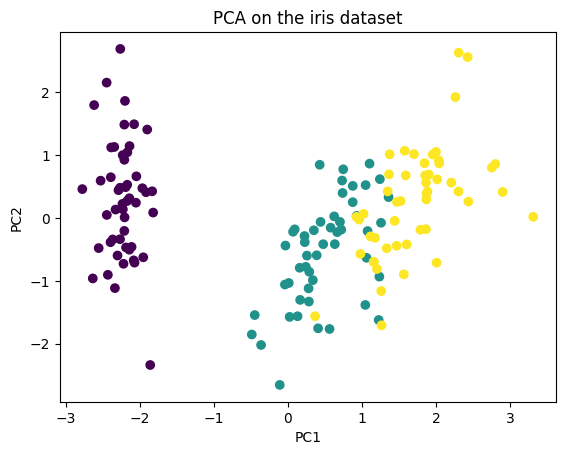

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X_pca[:, 0], X_pca[:, 1],c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA on the iris dataset")
plt.show()

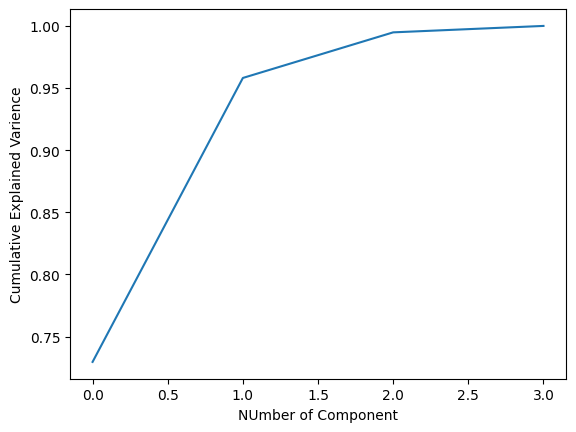

In [6]:
# Choosing number of components   
pca_full = PCA()
pca_full.fit(X_scaled)

import numpy as np 
import matplotlib.pyplot as plt 

plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("NUmber of Component")
plt.ylabel("Cumulative Explained Varience")
plt.show()